In [1]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

Historical

In [2]:
track_types = pd.read_csv('outputs/ibtracs_na_tracks_max_int.csv')

In [3]:
track_types['year'] = pd.to_datetime(track_types['date']).dt.year

In [4]:
years_era5, n_tracks_per_year_era5 = np.unique(track_types['year'], return_counts=True)

In [5]:
n_tarcks = len(track_types)
n_years = 2023 - 1981

n_tracks_per_year_hist = n_tarcks / n_years

#### Model

In [6]:
models = ['ec_earth3_veg_lr']
scenarios = ['historical', 'ssp245', 'ssp585']

In [7]:
n_tcs_per_year_per_model_scenario = {}

for model in models:

    for ssp in scenarios:
        print(f"Processing model: {model}, scenario: {ssp}")
        sim_tracks = xr.open_dataset(f'outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_{model}_{ssp}.nc')

        n_tcs_per_year_list = []

        for i in range(1):
            bmus = sim_tracks.isel(n_sim=i).evbmus_sims.values - 2
            _, counts = np.unique(bmus, return_counts=True)
            n_tcs = np.sum(counts[1:])
            n_years = pd.to_datetime(sim_tracks.time.values[-1]).year - pd.to_datetime(sim_tracks.time.values[0]).year
            n_tcs_per_year = n_tcs / n_years

            n_tcs_per_year_list.append(n_tcs_per_year)
        
        n_tcs_per_year_per_model_scenario[model + '_' + ssp] = n_tcs_per_year_list

Processing model: ec_earth3_veg_lr, scenario: historical
Processing model: ec_earth3_veg_lr, scenario: ssp245
Processing model: ec_earth3_veg_lr, scenario: ssp585


In [8]:
n_sims = 5
n_tcs_per_year_per_model_scenario = {}

for model in models:
    for ssp in scenarios:

        file = (f"outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_{model}_{ssp}.nc")
        sim_tracks = xr.open_dataset(file)

        n_years = pd.to_datetime(sim_tracks.time.values[-1]).year - pd.to_datetime(sim_tracks.time.values[0]).year + 1
        n_tcs_per_year_list = []

        for i in range(n_sims):
            bmus = (sim_tracks.isel(n_sim=i).evbmus_sims.values - 2)
            _, counts = np.unique(bmus,return_counts=True)

            n_tcs = np.sum(counts[1:])
            n_tcs_per_year = n_tcs / n_years
            n_tcs_per_year_list.append(n_tcs_per_year)

        key = f"{model}_{ssp}"
        n_tcs_per_year_per_model_scenario[key] = (n_tcs_per_year_list)

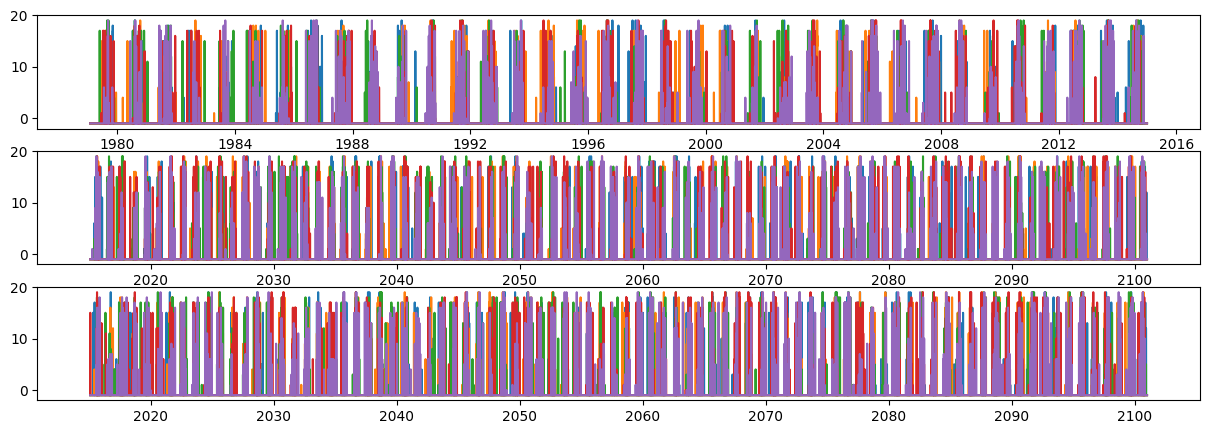

In [9]:
n_sims = 5
n_tcs_per_year_per_model_scenario = {}

for model in models:

    fig,axes = plt.subplots(3,1, figsize=(15, 5), sharey=True)
    counter=0
    for ssp in scenarios:

        file = f"outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_{model}_{ssp}.nc"
        sim_tracks = xr.open_dataset(file)
        n_years = (pd.to_datetime(sim_tracks.time.values[-1]).year - pd.to_datetime(sim_tracks.time.values[0]).year + 1)

        for i in range(n_sims):
            sim_tcs = sim_tracks.isel(n_sim=i).evbmus_sims.values - 2
            axes[counter].plot(sim_tracks.isel(n_sim=i).time.values,sim_tcs)

            n_tcs = np.sum(sim_tcs != -1)
            n_tcs_per_year = n_tcs / n_years
            
        counter+=1

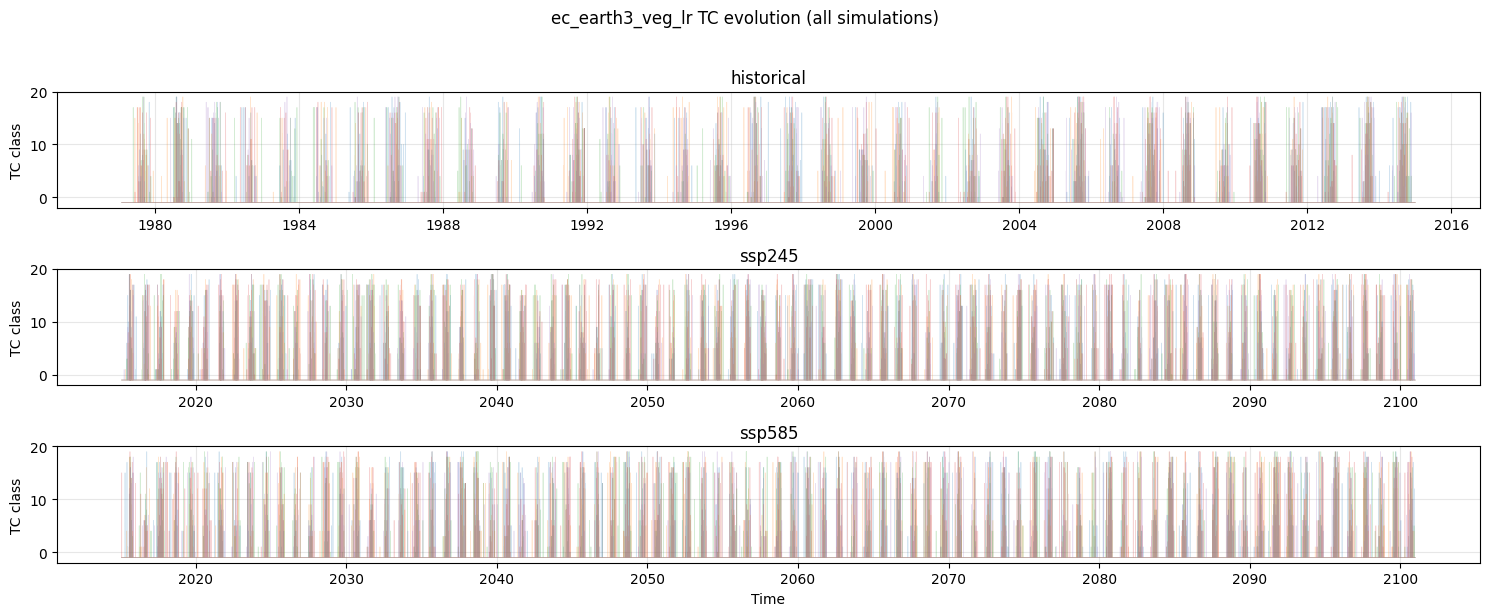

In [10]:
n_sims = 5

for model in models:

    fig, axes = plt.subplots(len(scenarios), 1, figsize=(15, 6), sharey=True)

    n_tcs_per_year_per_model_scenario = {}

    for j, ssp in enumerate(scenarios):

        file = f"outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_{model}_{ssp}.nc"
        sim_tracks = xr.open_dataset(file)

        years = (
            pd.to_datetime(sim_tracks.time.values[-1]).year
            - pd.to_datetime(sim_tracks.time.values[0]).year
            + 1
        )

        tc_per_year_list = []

        for i in range(n_sims):

            sim_tcs = sim_tracks.isel(n_sim=i).evbmus_sims.values - 2

            # ---- plot evolution ----
            axes[j].plot(
                sim_tracks.isel(n_sim=i).time.values,
                sim_tcs,
                alpha=0.2,
                linewidth=0.5
            )

            # ---- TC count ----
            n_tcs = np.sum(sim_tcs != -1)
            tc_per_year_list.append(n_tcs / years)

        n_tcs_per_year_per_model_scenario[f"{model}_{ssp}"] = tc_per_year_list

        axes[j].set_title(ssp)
        axes[j].set_ylabel("TC class")
        axes[j].grid(alpha=0.3)

    axes[-1].set_xlabel("Time")

    plt.suptitle(f"{model} TC evolution (all simulations)", y=1.02)
    plt.tight_layout()
    plt.show()

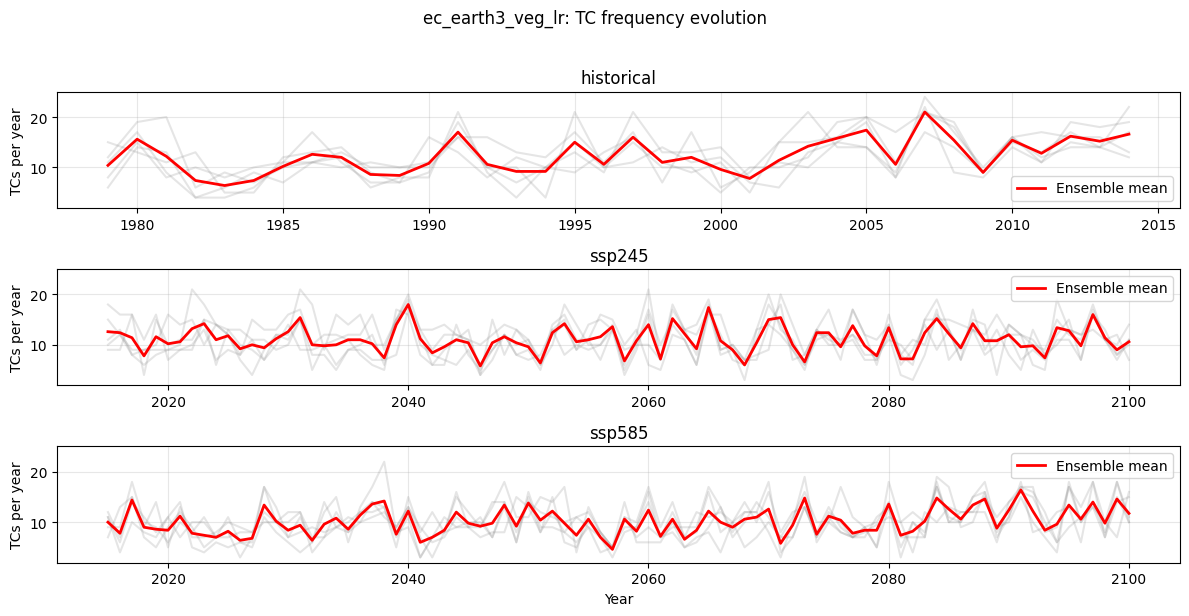

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_sims = 5

for model in models:

    fig, axes = plt.subplots(len(scenarios), 1, figsize=(12, 6), sharey=True)

    for j, ssp in enumerate(scenarios):

        file = f"outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_{model}_{ssp}.nc"
        sim_tracks = xr.open_dataset(file)

        time = pd.to_datetime(sim_tracks.time.values)

        all_years = []
        all_counts = []

        for i in range(n_sims):

            sim_tcs = sim_tracks.isel(n_sim=i).evbmus_sims.values - 2

            # -------------------------------------------------------------
            # detect TC "events" (entering TC state)
            # -------------------------------------------------------------
            events = np.diff((sim_tcs != -1).astype(int)) == 1

            event_times = time[1:][events]

            df = pd.DataFrame({"year": event_times.year})

            yearly_counts = df.value_counts().sort_index()

            all_years.append(yearly_counts.index.get_level_values(0))
            all_counts.append(yearly_counts.values)

            axes[j].plot(
                yearly_counts.index.get_level_values(0),
                yearly_counts.values,
                color="gray",
                alpha=0.2
            )

        # -------------------------------------------------------------
        # ensemble mean
        # -------------------------------------------------------------
        max_len = max(len(c) for c in all_counts)

        all_counts = np.array([
            np.pad(c.astype(float), (0, max_len - len(c)), constant_values=np.nan)
            for c in all_counts
        ])

        mean_counts = np.nanmean(all_counts, axis=0)

        axes[j].plot(
            sorted(set(np.concatenate(all_years))),
            mean_counts,
            color="red",
            linewidth=2,
            label="Ensemble mean"
        )

        axes[j].set_title(ssp)
        axes[j].set_ylabel("TCs per year")
        axes[j].grid(alpha=0.3)
        axes[j].legend()

    axes[-1].set_xlabel("Year")

    plt.suptitle(f"{model}: TC frequency evolution", y=1.02)
    plt.tight_layout()
    plt.show()

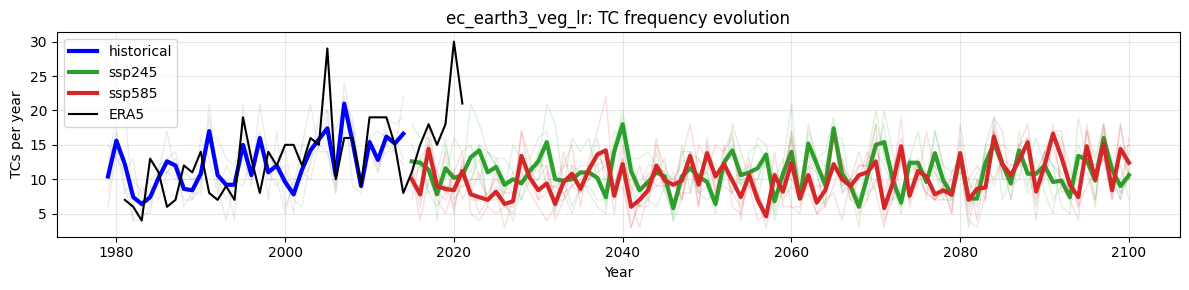

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

n_sims = 5

scenario_colors = {
    "ssp126": "tab:blue",
    "ssp245": "tab:green",
    "ssp370": "tab:orange",
    "ssp585": "tab:red",
}

for model in models:

    fig, ax = plt.subplots(figsize=(12, 3))

    for ssp in scenarios:

        file = f"outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_{model}_{ssp}.nc"
        sim_tracks = xr.open_dataset(file)

        time = pd.to_datetime(sim_tracks.time.values)

        all_years = []
        all_counts = []

        for i in range(n_sims):

            sim_tcs = sim_tracks.isel(n_sim=i).evbmus_sims.values - 2

            # Detect TC events (transition into TC state)
            events = np.diff((sim_tcs != -1).astype(int)) == 1

            event_times = time[1:][events]

            df = pd.DataFrame({"year": event_times.year})

            yearly_counts = df.value_counts().sort_index()

            years = yearly_counts.index.get_level_values(0).values
            counts = yearly_counts.values.astype(float)

            all_years.append(years)
            all_counts.append(counts)

            # Plot individual simulations lightly
            ax.plot(
                years,
                counts,
                color=scenario_colors.get(ssp, "gray"),
                alpha=0.15,
                linewidth=1
            )

        # -------------------------------------------------------------
        # Ensemble mean
        # -------------------------------------------------------------
        unique_years = sorted(set(np.concatenate(all_years)))

        aligned_counts = []

        for years, counts in zip(all_years, all_counts):

            s = pd.Series(counts, index=years)
            s = s.reindex(unique_years)

            aligned_counts.append(s.values)

        aligned_counts = np.array(aligned_counts)

        mean_counts = np.nanmean(aligned_counts, axis=0)

        ax.plot(
            unique_years,
            mean_counts,
            color=scenario_colors.get(ssp, "blue"),
            linewidth=3,
            label=ssp
        )

    ax.plot(years_era5, n_tracks_per_year_era5, color='k', label='ERA5')

    ax.set_title(f"{model}: TC frequency evolution")
    ax.set_xlabel("Year")
    ax.set_ylabel("TCs per year")
    ax.grid(alpha=0.3)
    ax.legend()



    plt.tight_layout()
    plt.show()

In [13]:
track_types
hist_tracks = xr.open_dataset('inputs/ibtracs_na_tracks.nc')